# IY022: Normalisation Methods in Contrastive Learning

In [1]:
import torch
import torch.optim as optim
from pathlib import Path
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from dataloaders.simclr import ssl_data_prep
from dataloaders import  save_loader_to_disk
from models.ssl_transformer import SSL_Transformer
from training.train import train_ssl_model
from info_nce import InfoNCE
import wandb
%load_ext autoreload
%autoreload 2  

In [2]:
# Setup Configuration
DATA_ROOT = Path("/home/ianyang/stochastic_simulations/experiments/EXP-26-IY020/data")
RESULTS_PATH = DATA_ROOT / "IY020_simulation_parameters_sobol.csv" #  this csv file stores all the simulation parameters used
df_params = pd.read_csv(RESULTS_PATH) 
# filter out only successful simulations with no error_message, and mean_rel_error_pct < 10, cv_rel_error_pct  < 10, & t_ac_rel_error_pct < 10
df_params = df_params[(df_params['success'] == True) & 
                    (df_params['error_message'].isna()) &
                    (df_params['mean_rel_error_pct'] < 10) & 
                    (df_params['cv_rel_error_pct'] < 10) & 
                    (df_params['t_ac_rel_error_pct'] < 10)]
TRAJ_PATH = [DATA_ROOT / df_params['trajectory_filename'].values[i] for i in range(len(df_params))]
TRAJ_NPZ_PATH = [traj_file.with_suffix('.npz') for traj_file in TRAJ_PATH]
print(f"Number of VALID trajectories: {len(TRAJ_PATH)}")

Number of VALID trajectories: 7709


```
normalisation: 'instance'
```

In [3]:
# === Dataloader hyperparams & data prep ===
batch_size = 64
num_traj=1 # number of trajectories per view
sample_len=None
log_scale = False 
normalisation = 'instance'

train_loader, val_loader, test_loader = ssl_data_prep(
    # TRAJ_NPZ_PATH,
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
# === Dataloader hyperparams & data prep ===
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([64, 3000, 1]) torch.Size([64, 3000, 1]) torch.Size([64, 1])


--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


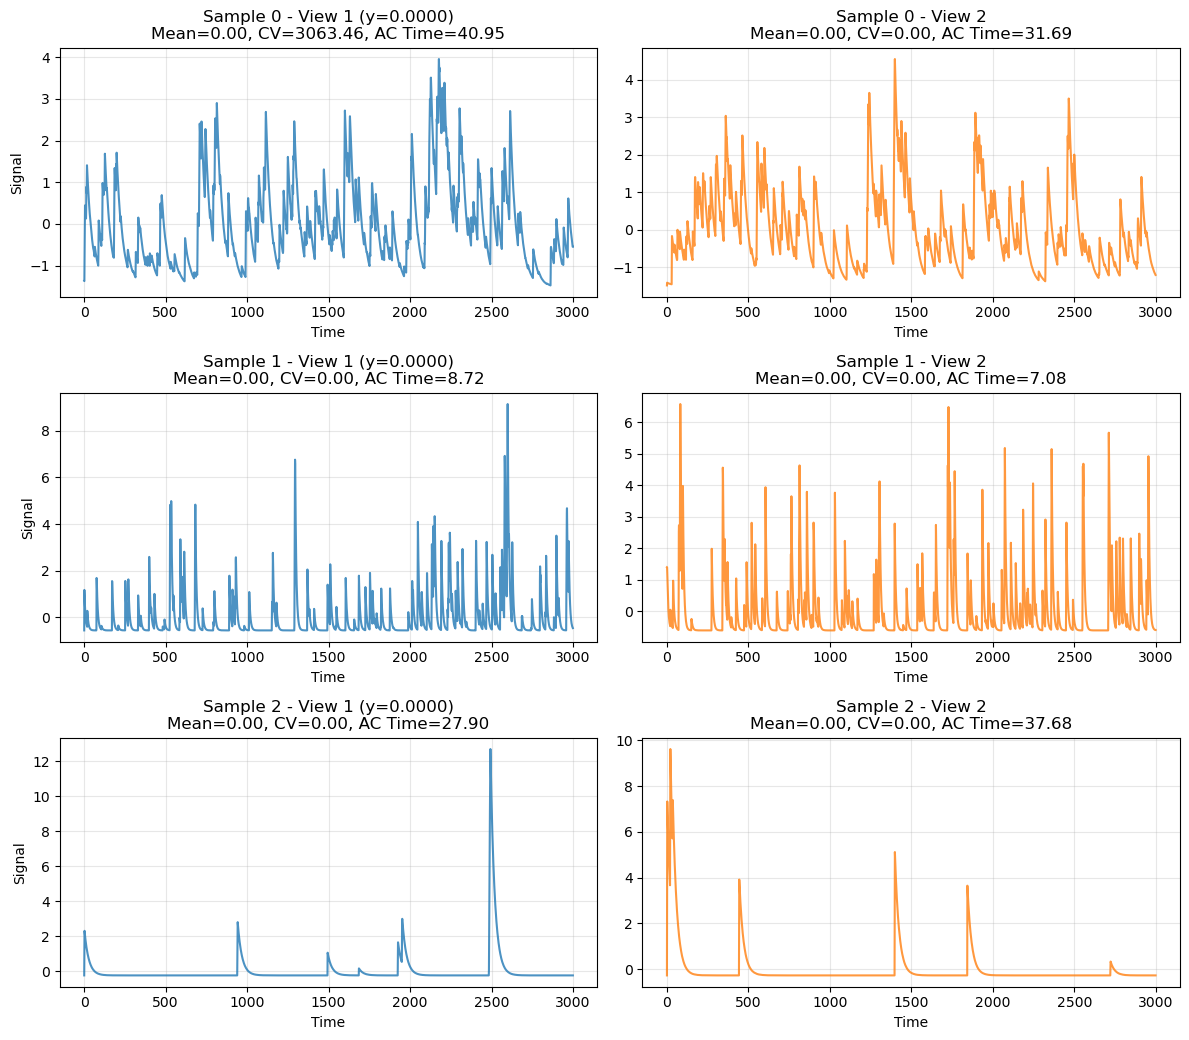

--- Validation Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


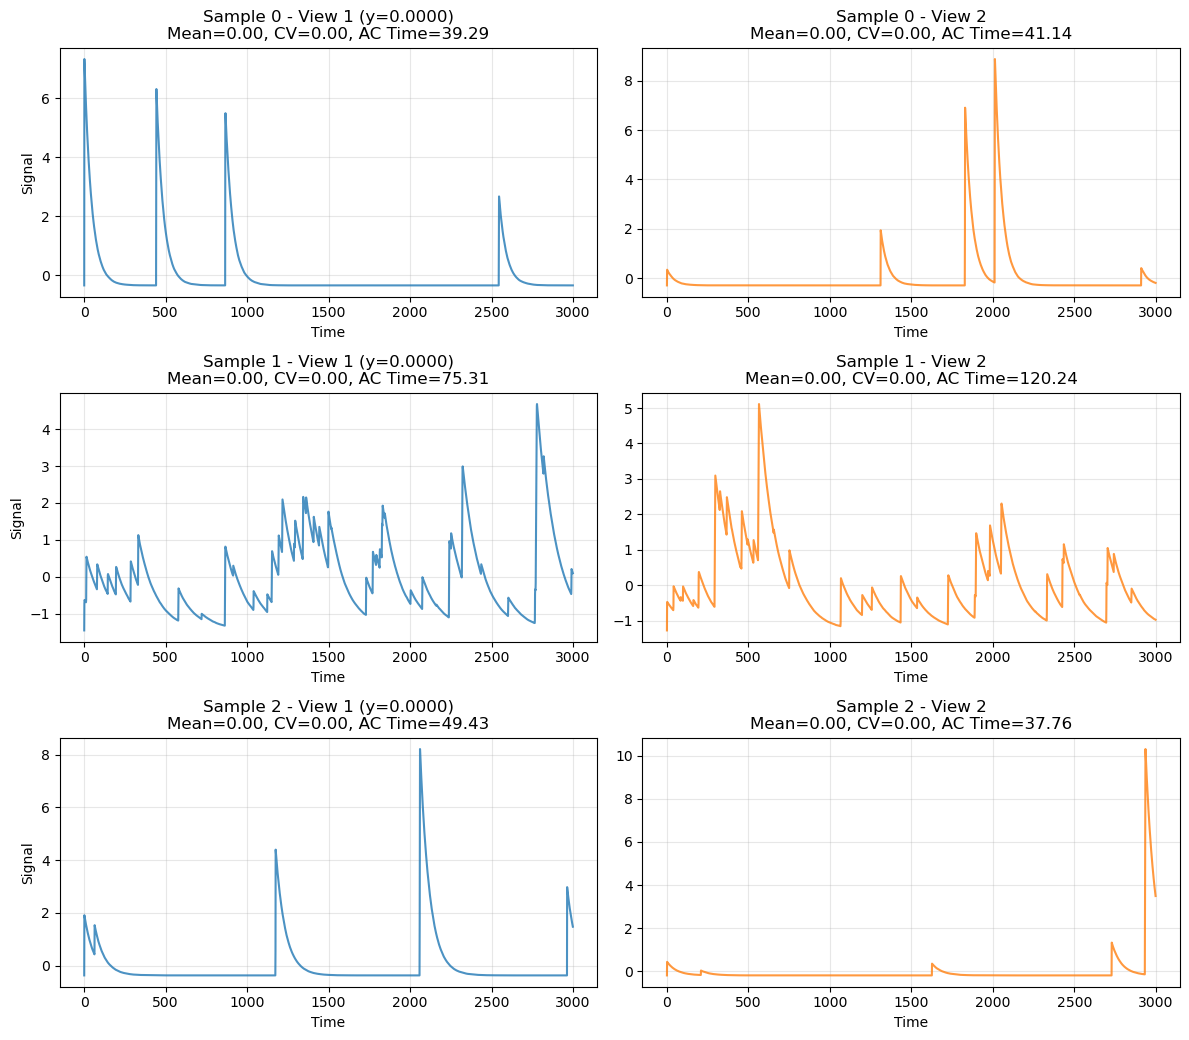

--- Test Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


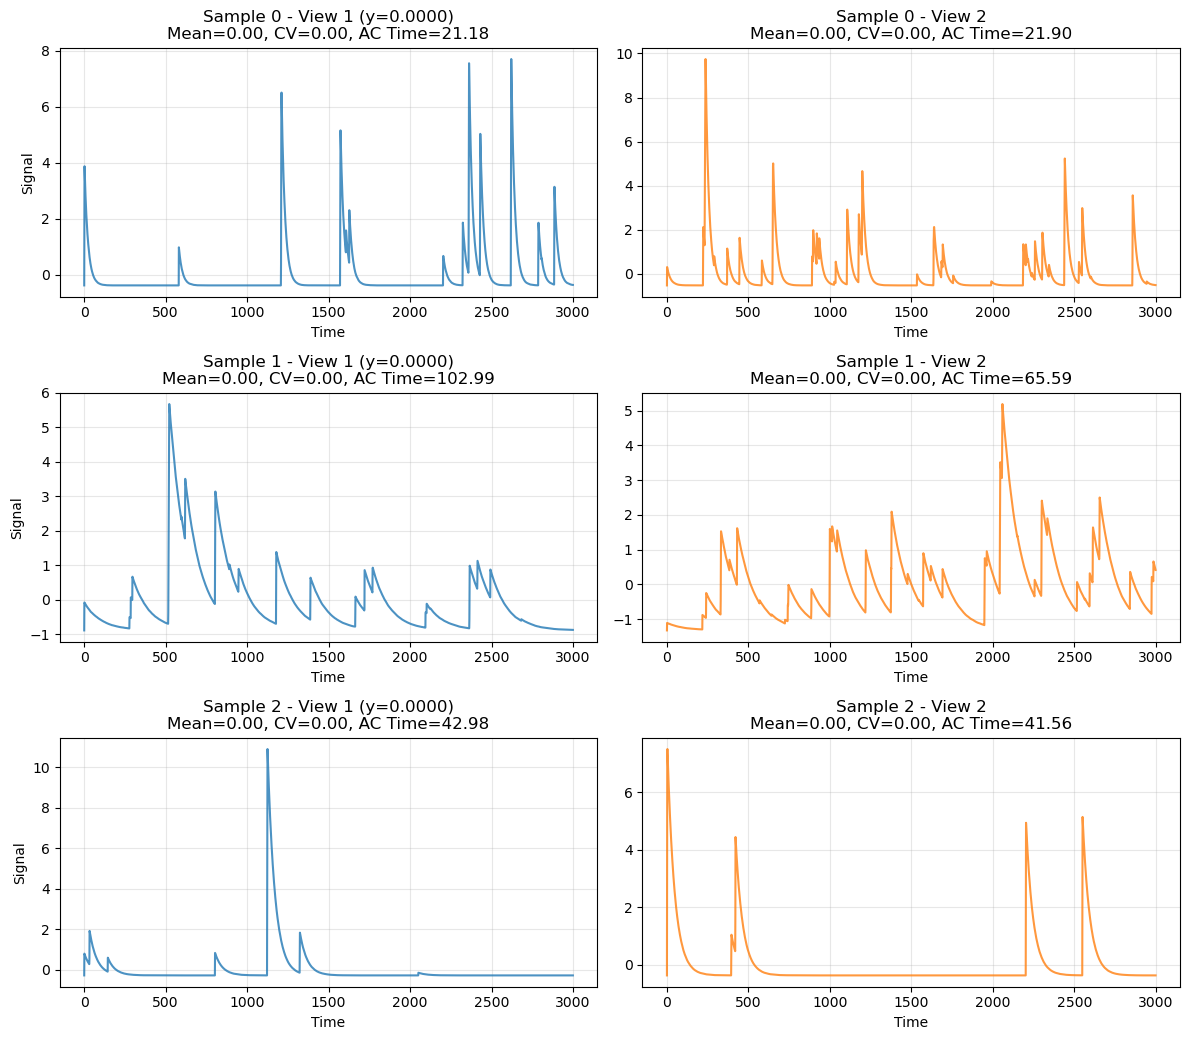

In [4]:
from stats.autocorrelation import calculate_autocorrelation, calculate_ac_time_interp1d

def visualize_loader_samples(loader, loader_name, num_samples=3):
    """
    Visualizes samples from the dataloader including Mean and CV statistics.
    Assumes loader returns (X1, X2, y) for SSL or (X, y) for standard tasks.
    """
    if not loader:
        print(f"{loader_name} is None or empty.")
        return
        
    iterator = iter(loader)
    try:
        batch = next(iterator)
    except StopIteration:
        print(f"Could not fetch batch from {loader_name}")
        return

    # Check batch structure
    if len(batch) == 3:
        X1, X2, y = batch
        has_two_views = True
        print(f"--- {loader_name} (SSL Pairs) ---")
        print(f"Shapes :: X1: {X1.shape}, X2: {X2.shape}, y: {y.shape}")
    elif len(batch) == 2:
        X1, y = batch
        X2 = None
        has_two_views = False
        print(f"--- {loader_name} (Standard) ---")
        print(f"Shapes :: X: {X1.shape}, y: {y.shape}")
    else:
        print(f"Unexpected batch format length: {len(batch)}")
        return

    # Plotting
    cols = 2 if has_two_views else 1
    fig, axes = plt.subplots(num_samples, cols, figsize=(12, 3.5 * num_samples), squeeze=False)
    
    for i in range(min(num_samples, len(X1))):
        label_str = f"{y[i].item():.4f}" if y[i].numel() == 1 else "Vector"
        
        # Stats for View 1
        x1_data = X1[i].flatten().cpu().numpy()
        mu1, std1 = np.mean(x1_data), np.std(x1_data)
        cv1 = std1 / abs(mu1) if abs(mu1) > 1e-5 else 0
        autocorr_results1 = calculate_autocorrelation(x1_data)
        ac_mean1 = autocorr_results1["stress_ac"].mean(axis=0)
        lags1 = autocorr_results1["stress_lags"]
        ac_time_observed1 = calculate_ac_time_interp1d(ac_mean1, lags1)

        # Plot View 1
        ax1 = axes[i, 0]
        ax1.plot(x1_data, color='tab:blue', alpha=0.8)
        ax1.set_title(f"Sample {i} - View 1 (y={label_str})\nMean={abs(mu1):.2f}, CV={abs(cv1):.2f}, AC Time={ac_time_observed1:.2f}")
        ax1.set_xlabel("Time")
        ax1.set_ylabel("Signal")
        ax1.grid(True, alpha=0.3)
        
        # Plot View 2 if exists
        if has_two_views:
            x2_data = X2[i].flatten().cpu().numpy()
            mu2, std2 = np.mean(x2_data), np.std(x2_data)
            cv2 = std2 / abs(mu2) if abs(mu2) > 1e-5 else 0
            autocorr_results2 = calculate_autocorrelation(x2_data)
            ac_mean2 = autocorr_results2["stress_ac"].mean(axis=0)
            lags2 = autocorr_results2["stress_lags"]
            ac_time_observed2 = calculate_ac_time_interp1d(ac_mean2, lags2)

            ax2 = axes[i, 1]
            ax2.plot(x2_data, color='tab:orange', alpha=0.8)
            ax2.set_title(f"Sample {i} - View 2\nMean={abs(mu2):.2f}, CV={abs(cv2):.2f}, AC Time={ac_time_observed2:.2f}")
            ax2.set_xlabel("Time")
            ax2.grid(True, alpha=0.3)
            
    plt.tight_layout()
    plt.show()

# Visualize samples
visualize_loader_samples(train_loader, "Train Loader")
if 'val_loader' in locals(): visualize_loader_samples(val_loader, "Validation Loader")
if 'test_loader' in locals(): visualize_loader_samples(test_loader, "Test Loader")

```
normalisation: 'global'
```

In [5]:
# === Dataloader hyperparams & data prep ===
batch_size = 64
num_traj=1 # number of trajectories per view
sample_len=None
log_scale = False 
normalisation = 'global'

train_loader, val_loader, test_loader = ssl_data_prep(
    # TRAJ_NPZ_PATH,
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
# === Dataloader hyperparams & data prep ===
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([64, 3000, 1]) torch.Size([64, 3000, 1]) torch.Size([64, 1])


--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


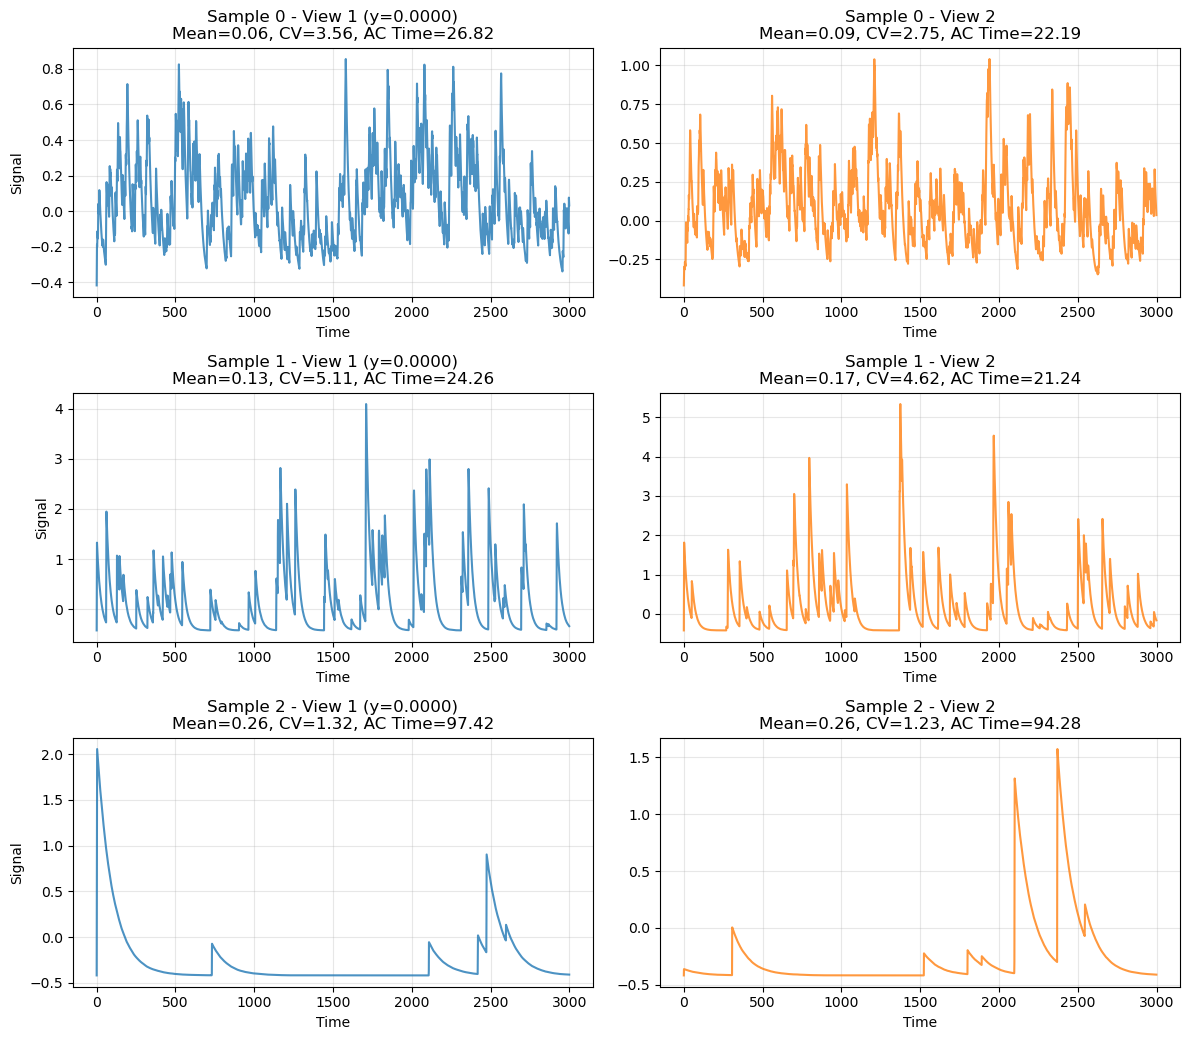

--- Validation Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


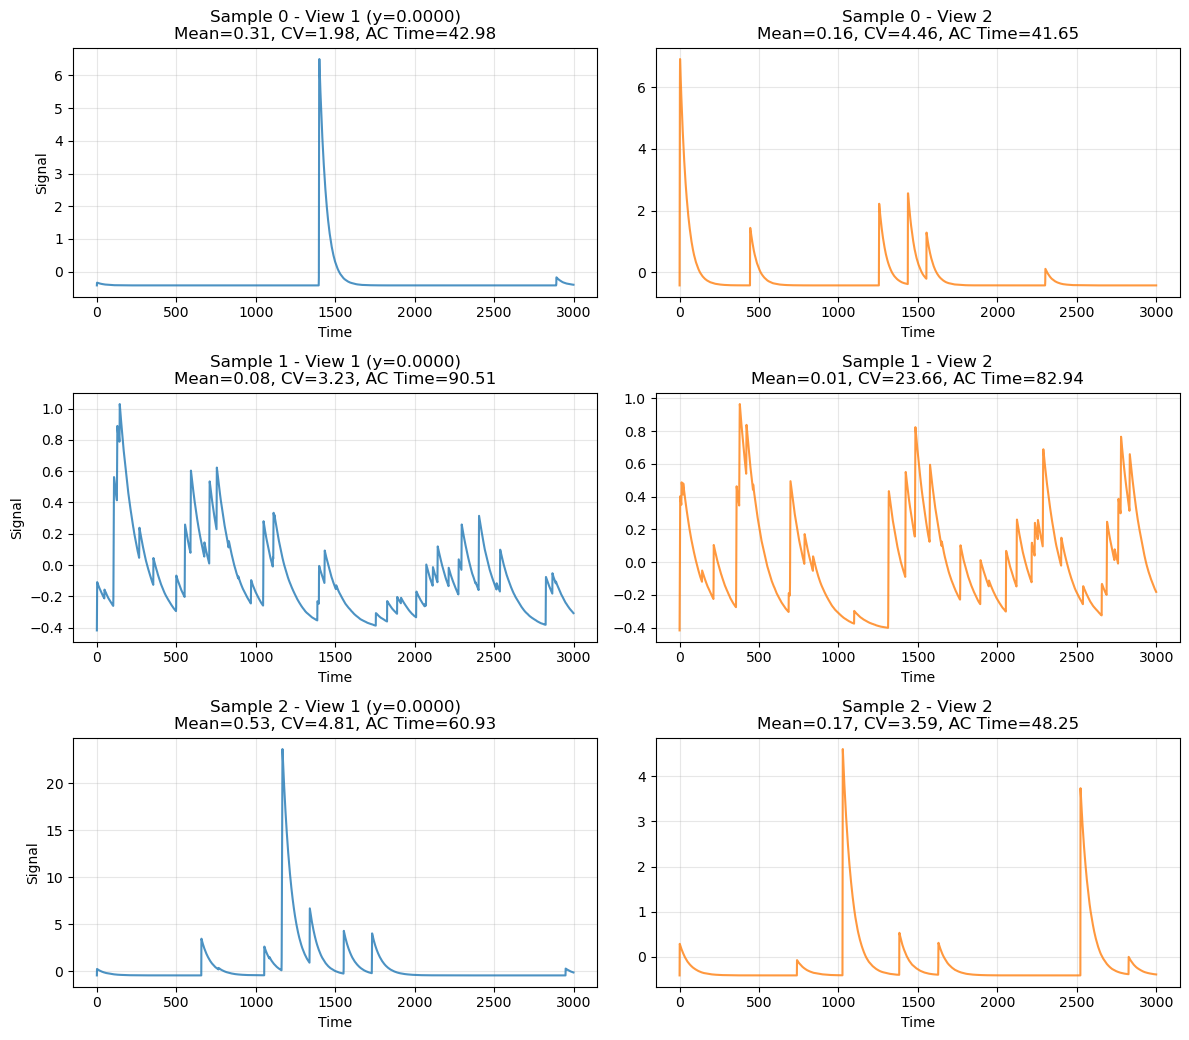

--- Test Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


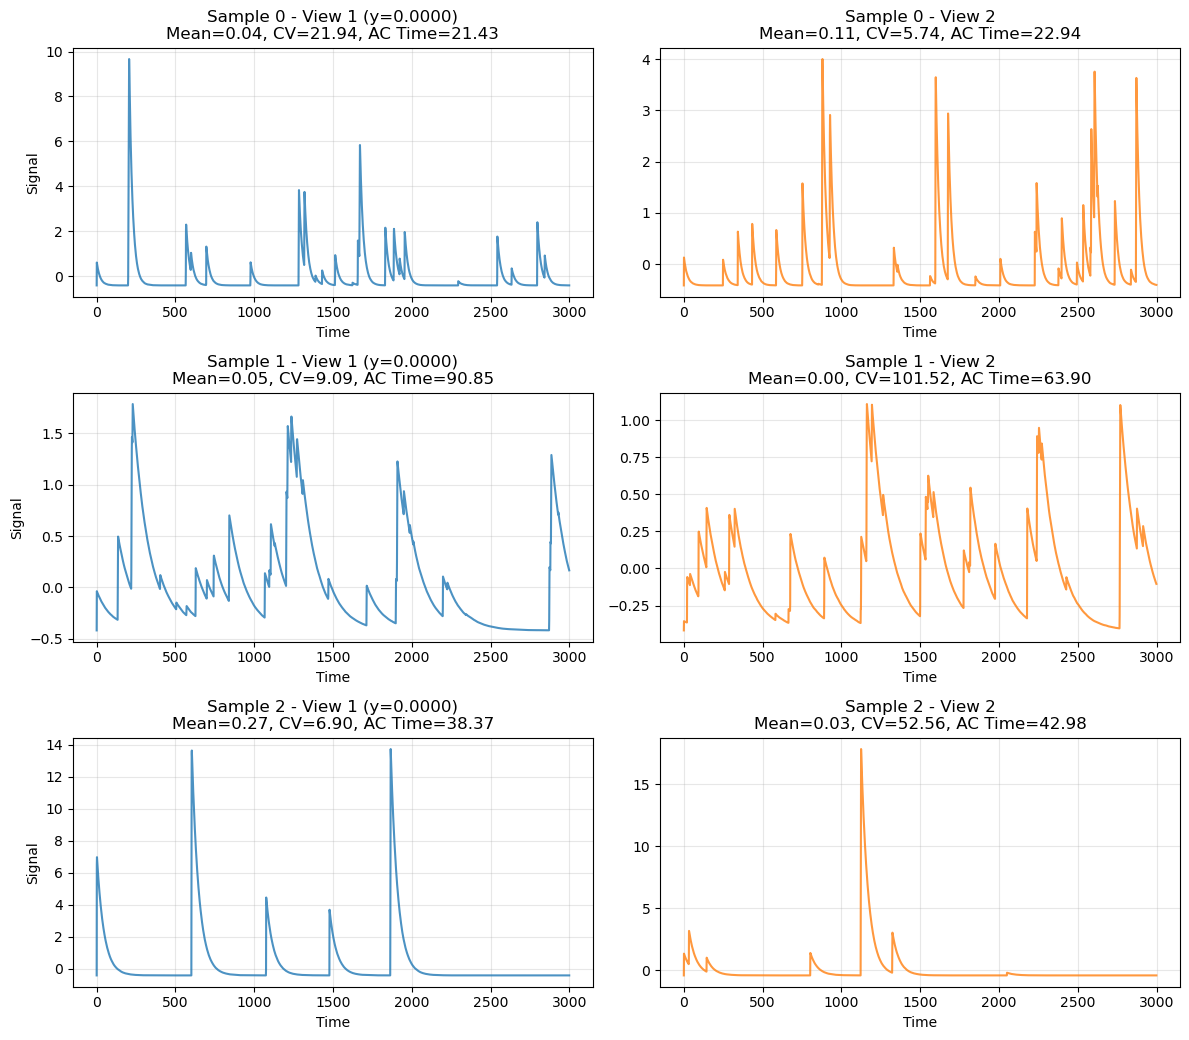

In [6]:
# Visualize samples
visualize_loader_samples(train_loader, "Train Loader")
if 'val_loader' in locals(): visualize_loader_samples(val_loader, "Validation Loader")
if 'test_loader' in locals(): visualize_loader_samples(test_loader, "Test Loader")

```
normalisation: 'joint'
```

In [7]:
# === Dataloader hyperparams & data prep ===
batch_size = 64
num_traj=1 # number of trajectories per view
sample_len=None
log_scale = False 
normalisation = 'joint'

train_loader, val_loader, test_loader = ssl_data_prep(
    # TRAJ_NPZ_PATH,
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
# === Dataloader hyperparams & data prep ===
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([64, 3000, 1]) torch.Size([64, 3000, 1]) torch.Size([64, 1])


--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


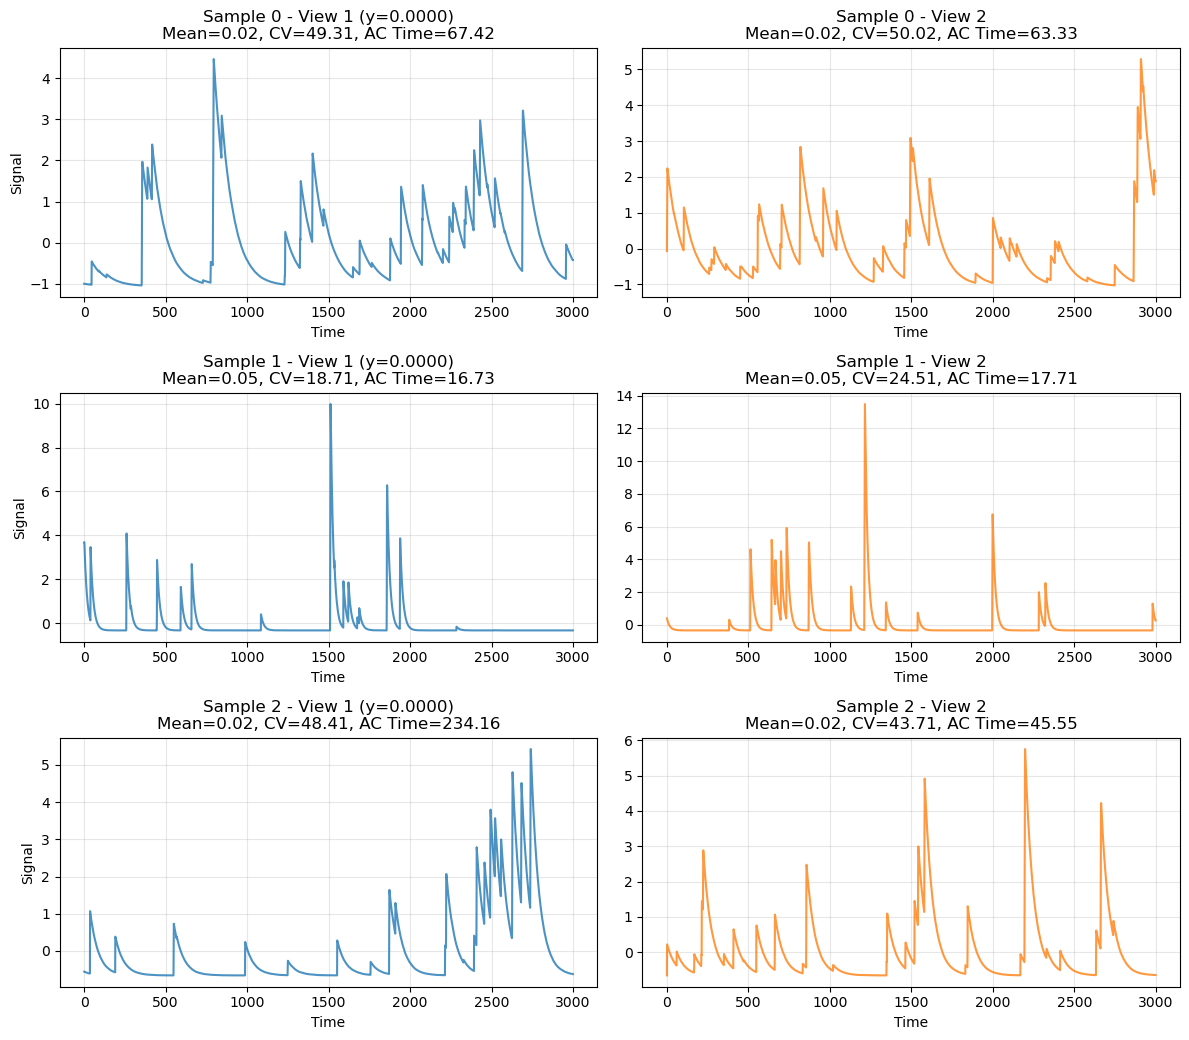

--- Validation Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


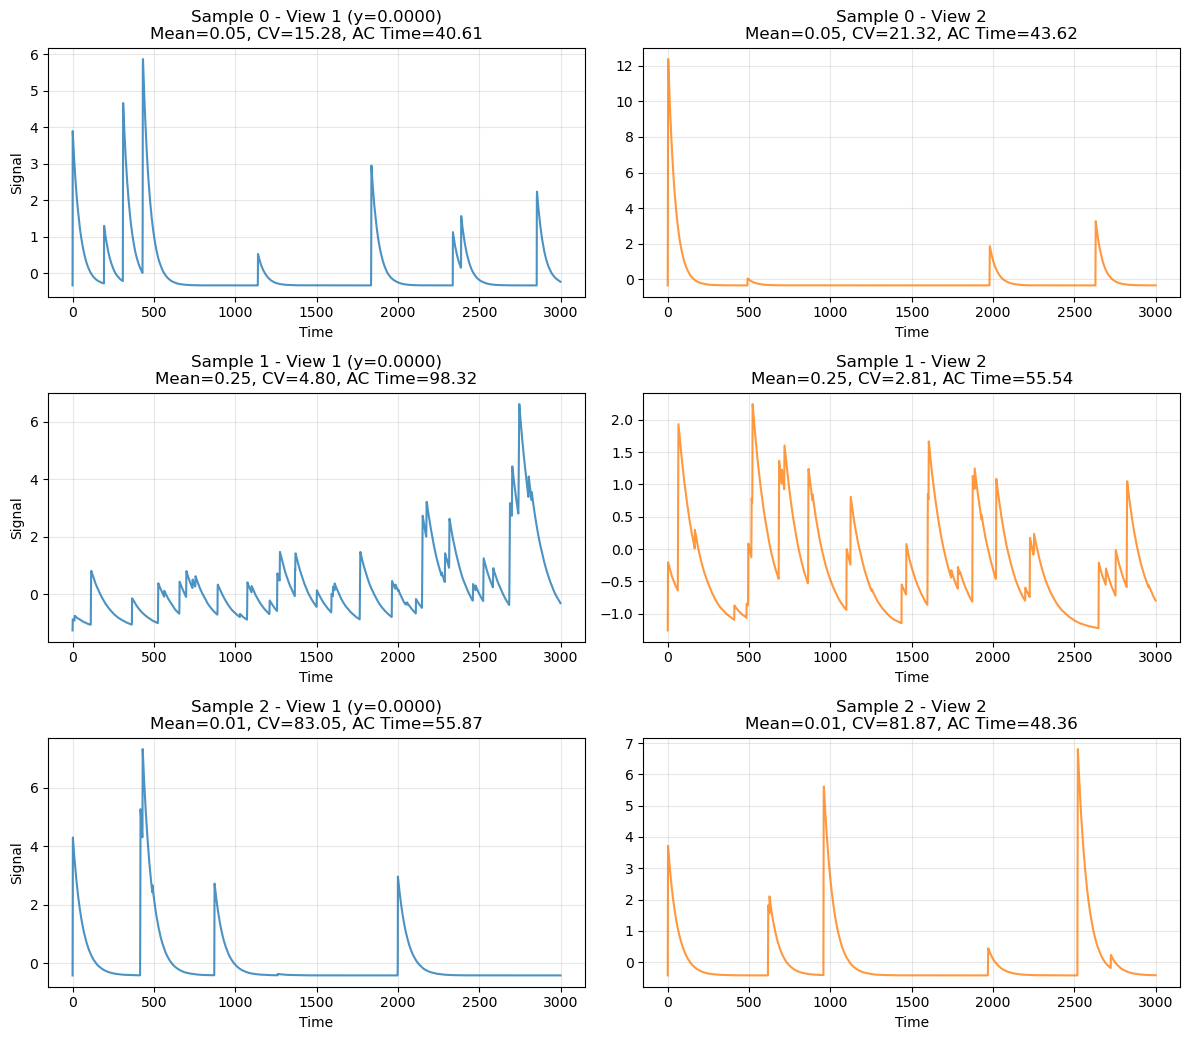

--- Test Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


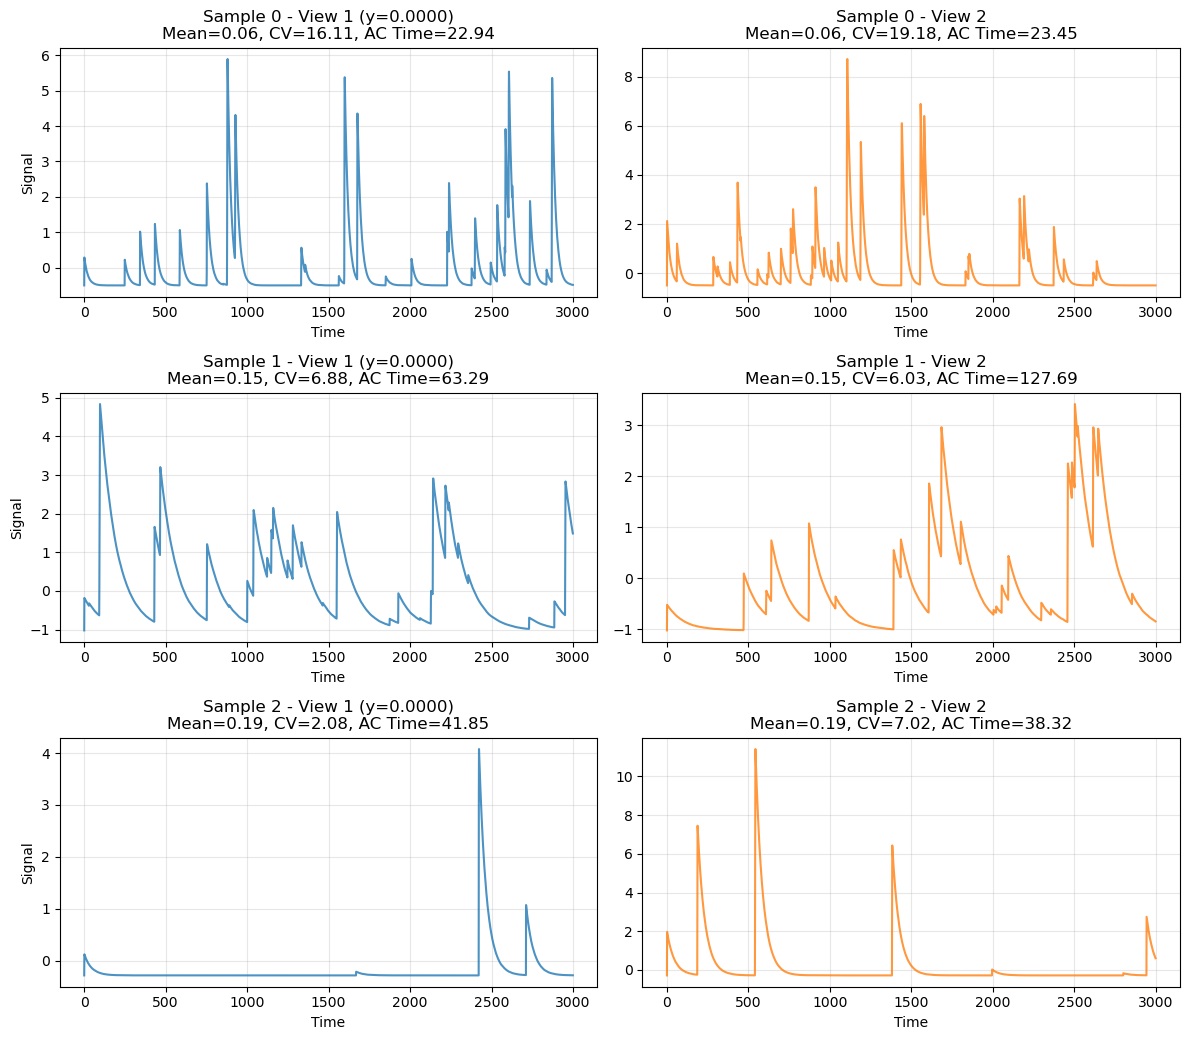

In [8]:
# Visualize samples
visualize_loader_samples(train_loader, "Train Loader")
if 'val_loader' in locals(): visualize_loader_samples(val_loader, "Validation Loader")
if 'test_loader' in locals(): visualize_loader_samples(test_loader, "Test Loader")

```
normalisation: 'batch-wise'
```

In [9]:
# === Dataloader hyperparams & data prep ===
batch_size = 64
num_traj=1 # number of trajectories per view
sample_len=None
log_scale = False 
normalisation = 'batch-wise'

train_loader, val_loader, test_loader = ssl_data_prep(
    # TRAJ_NPZ_PATH,
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
)
# === Dataloader hyperparams & data prep ===
X1_b, X2_b, y_b = next(iter(train_loader))
print(X1_b.shape, X2_b.shape, y_b.shape) # (B, T, 1) (B, T, 1) (B, 1)

torch.Size([64, 3000, 1]) torch.Size([64, 3000, 1]) torch.Size([64, 1])


--- Train Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


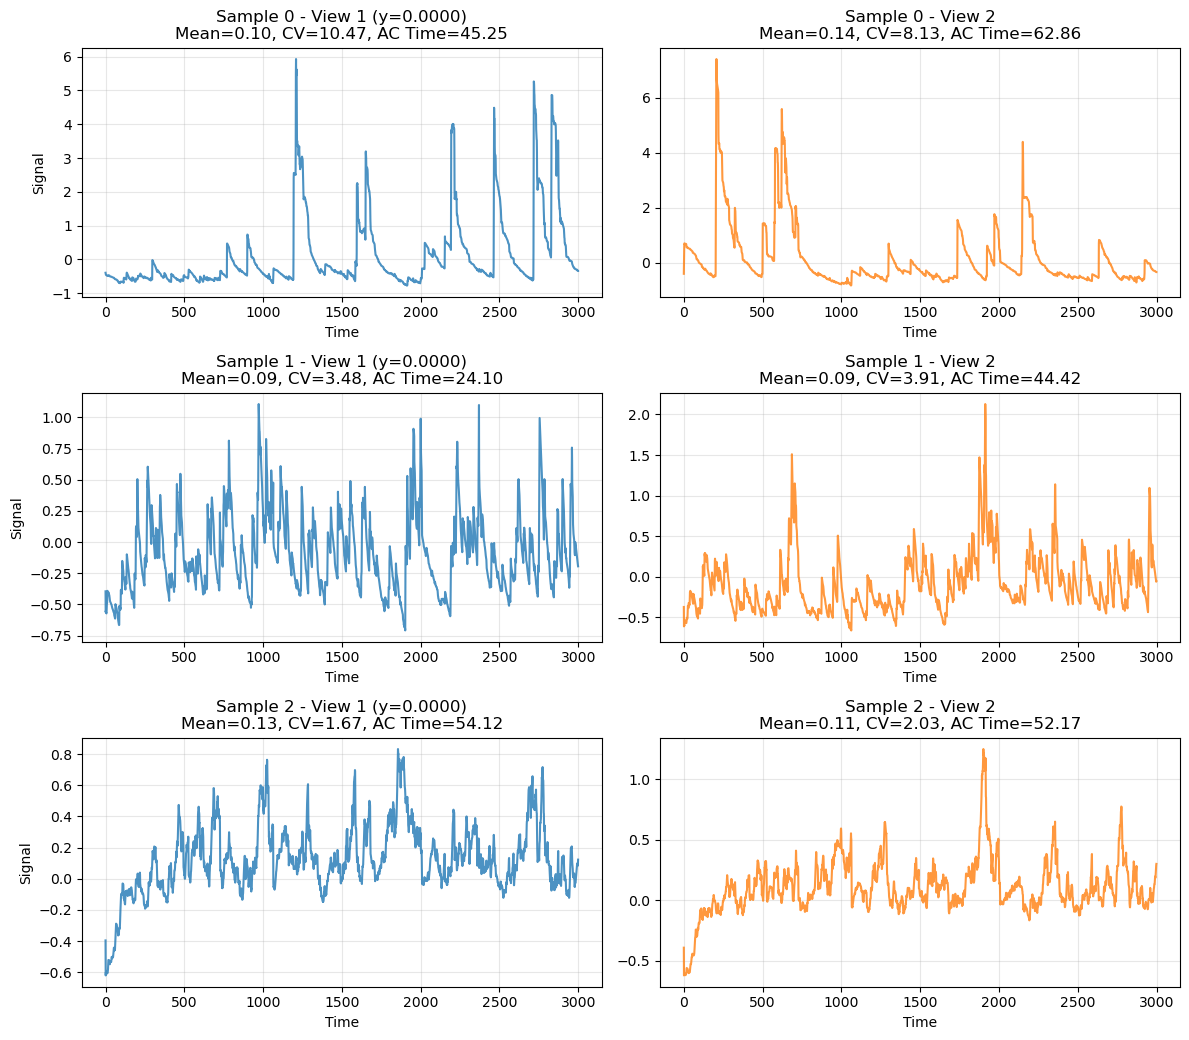

--- Validation Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


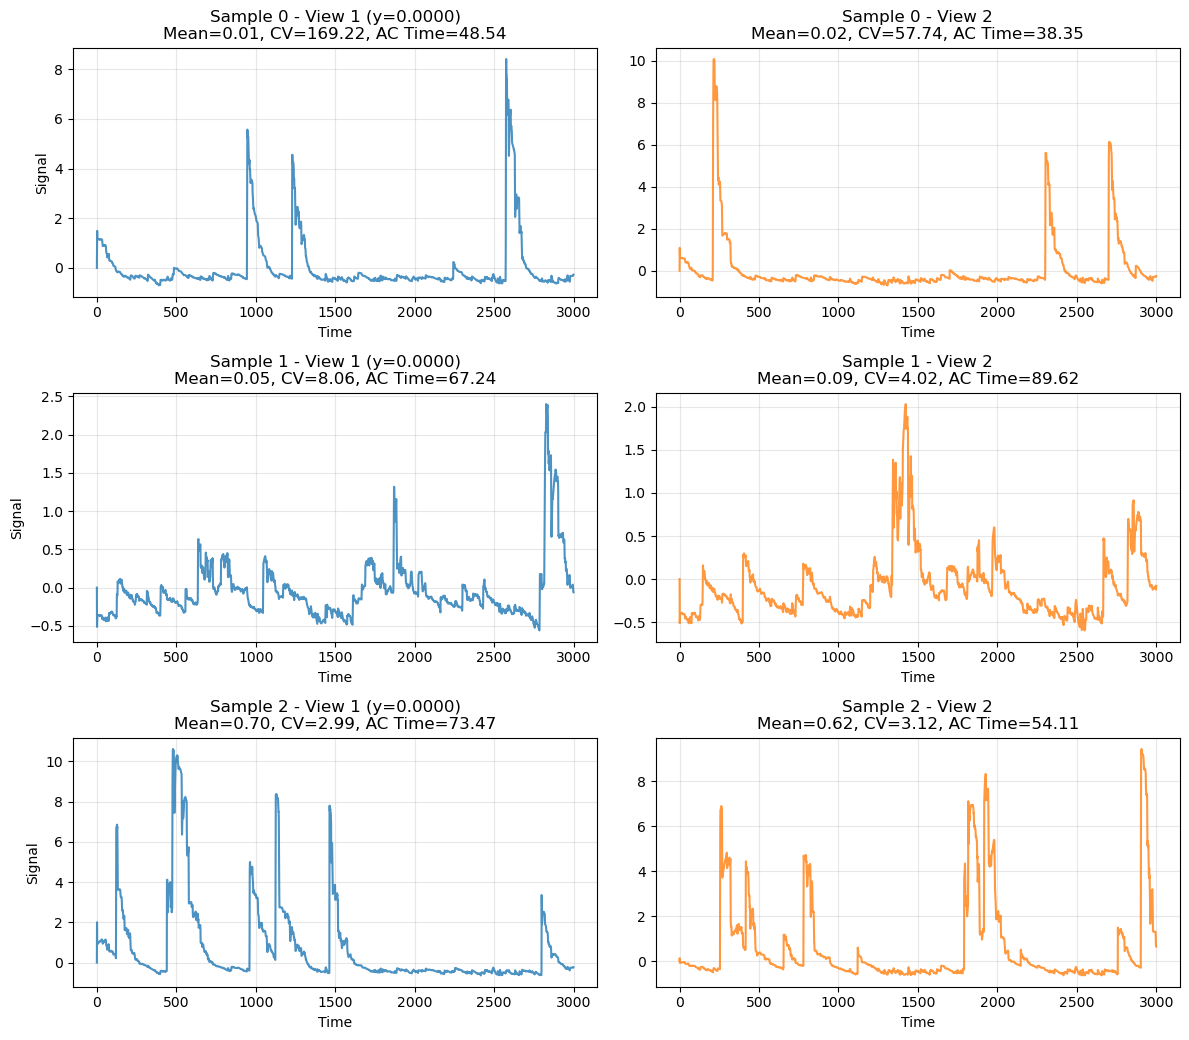

--- Test Loader (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


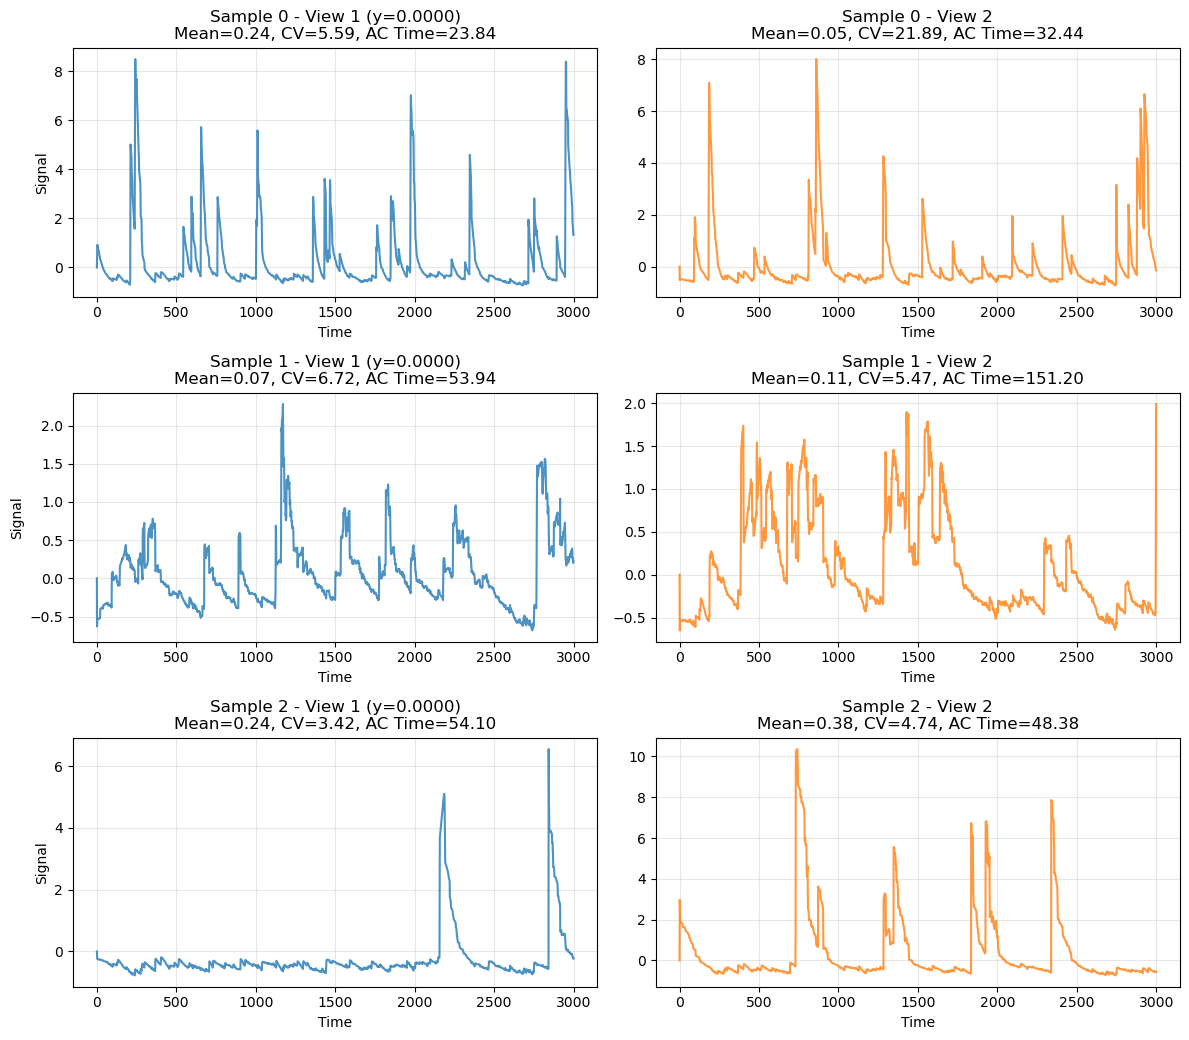

In [10]:
# Visualize samples
visualize_loader_samples(train_loader, "Train Loader")
if 'val_loader' in locals(): visualize_loader_samples(val_loader, "Validation Loader")
if 'test_loader' in locals(): visualize_loader_samples(test_loader, "Test Loader")

```
normalisation: 'global' — Welford streaming stats (exact over ALL training files)
```

Previously, `'global'` normalisation estimated mean/std from a random sample of 200 files, which is fragile and may not represent the full dataset distribution.  
This section uses the **updated implementation** where `ssl_data_prep` streams through every training file using **Chan's parallel (Welford) algorithm** — O(1) memory, single pass, exact statistics.

In [ ]:
# === Dataloader hyperparams & data prep (Welford global norm) ===
batch_size = 64
num_traj = 1        # number of trajectories per view
sample_len = None
log_scale = False   # Welford stats computed without log transform
normalisation = 'global'   # ssl_data_prep now uses Welford streaming internally

train_loader_welford, val_loader_welford, test_loader_welford = ssl_data_prep(
    TRAJ_PATH,
    batch_size=batch_size,
    sample_len=sample_len,
    log_scale=log_scale,
    normalisation=normalisation,
    num_traj=num_traj,
    verbose=True,   # prints Welford stats: N values, mean, std
)
# === Dataloader hyperparams & data prep (Welford global norm) ===
X1_b_w, X2_b_w, y_b_w = next(iter(train_loader_welford))
print(X1_b_w.shape, X2_b_w.shape, y_b_w.shape)  # (B, T, 1) (B, T, 1) (B, 1)

Files split: 4933 Train, 1234 Val, 1542 Test
Calculating Global Normalisation Stats (Welford streaming over ALL training files)...


Welford global stats:   5%|▌         | 259/4933 [00:35<14:39,  5.32it/s]

Welford global stats:  67%|██████▋   | 3299/4933 [08:09<04:07,  6.59it/s]

--- Train Loader (Welford global norm) (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


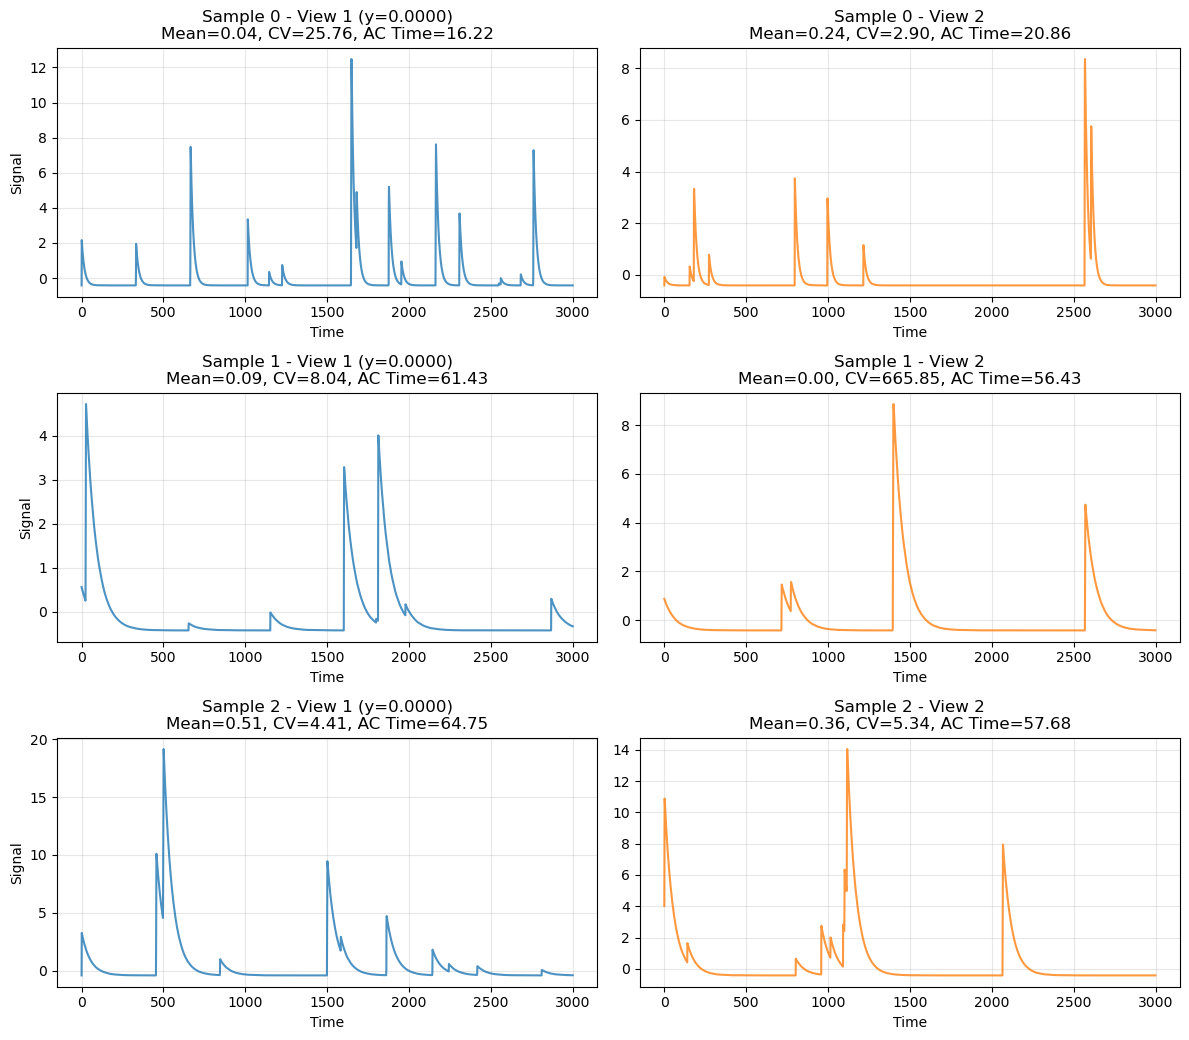

--- Validation Loader (Welford global norm) (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


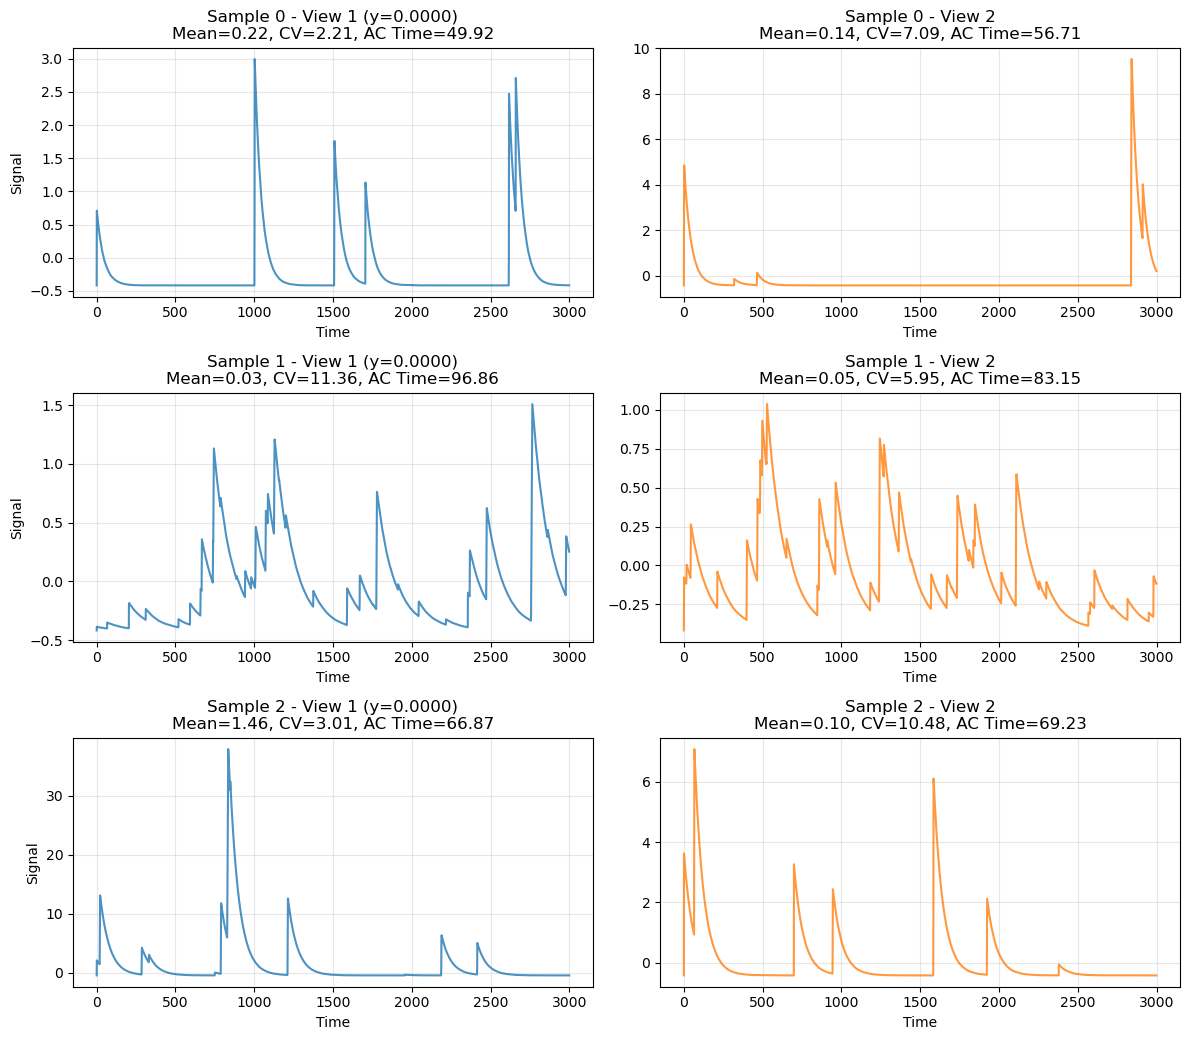

--- Test Loader (Welford global norm) (SSL Pairs) ---
Shapes :: X1: torch.Size([64, 3000, 1]), X2: torch.Size([64, 3000, 1]), y: torch.Size([64, 1])


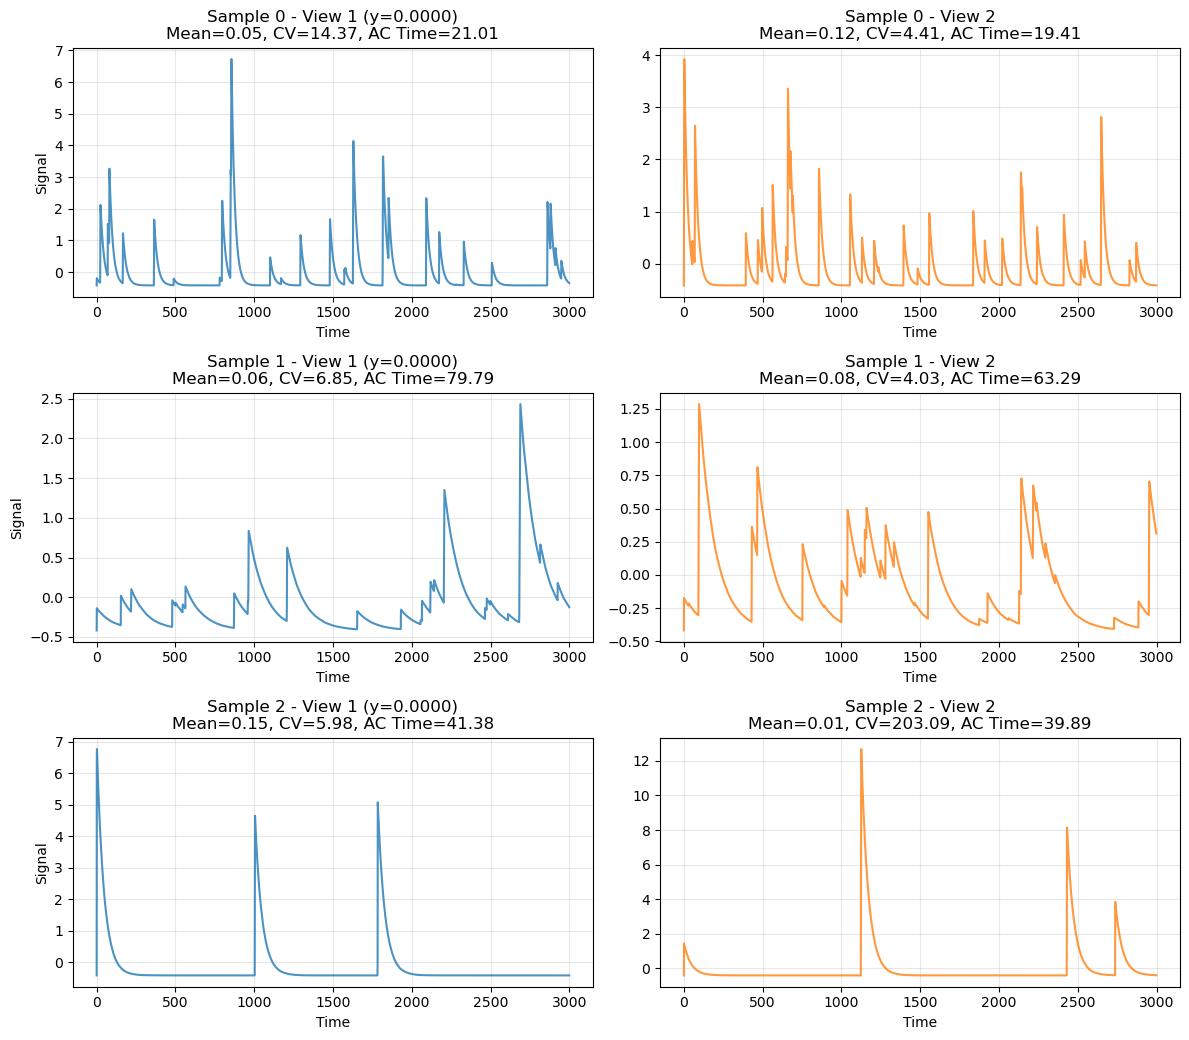

In [ ]:
# Visualize samples — Welford global norm
visualize_loader_samples(train_loader_welford, "Train Loader (Welford global norm)")
if 'val_loader_welford' in locals(): visualize_loader_samples(val_loader_welford, "Validation Loader (Welford global norm)")
if 'test_loader_welford' in locals(): visualize_loader_samples(test_loader_welford, "Test Loader (Welford global norm)")